
[coins] 24 circulo(s) detectado(s)
   centro=(349, 187)  radio=31px
   centro=(172, 256)  radio=30px
   centro=(335, 45)  radio=29px
   centro=(45, 259)  radio=29px
   centro=(272, 118)  radio=25px
   centro=(299, 263)  radio=24px
   centro=(244, 263)  radio=23px
   centro=(213, 193)  radio=23px
   centro=(215, 51)  radio=23px
   centro=(154, 52)  radio=23px
   centro=(103, 195)  radio=22px
   centro=(113, 266)  radio=21px
   centro=(359, 268)  radio=21px
   centro=(154, 197)  radio=20px
   centro=(44, 124)  radio=20px
   centro=(277, 195)  radio=19px
   centro=(337, 125)  radio=19px
   centro=(43, 199)  radio=19px
   centro=(46, 55)  radio=19px
   centro=(103, 125)  radio=18px
   centro=(274, 52)  radio=18px
   centro=(155, 127)  radio=18px
   centro=(103, 57)  radio=18px
   centro=(205, 125)  radio=18px


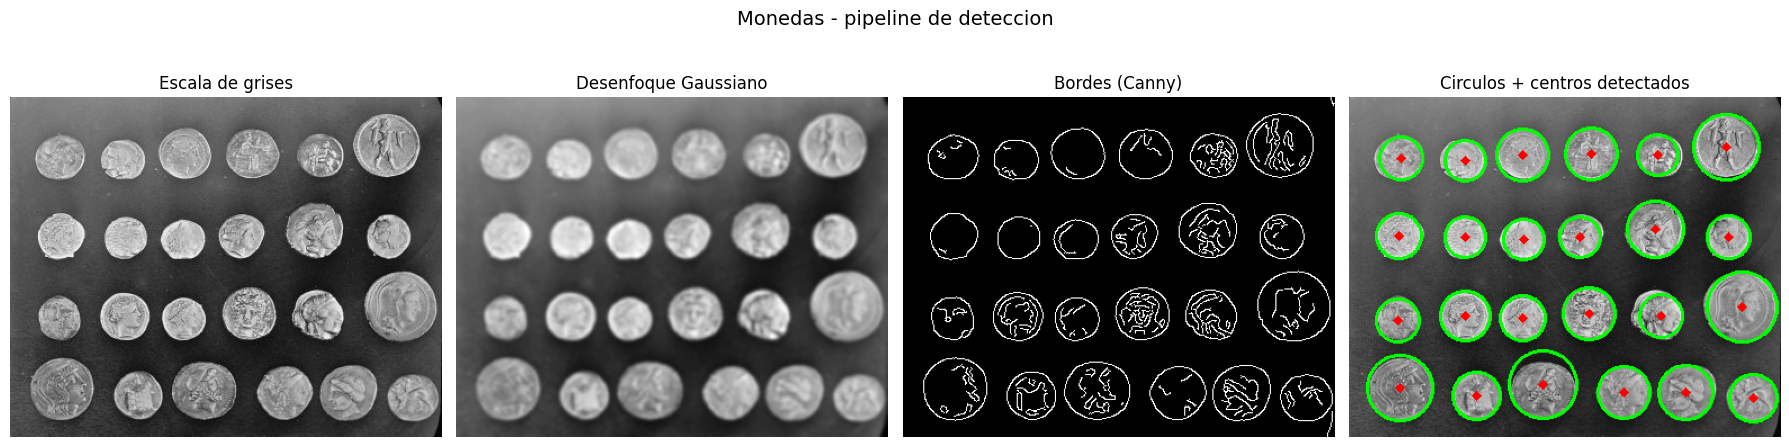


[clock] 1 circulo(s) detectado(s)
   centro=(208, 148)  radio=52px


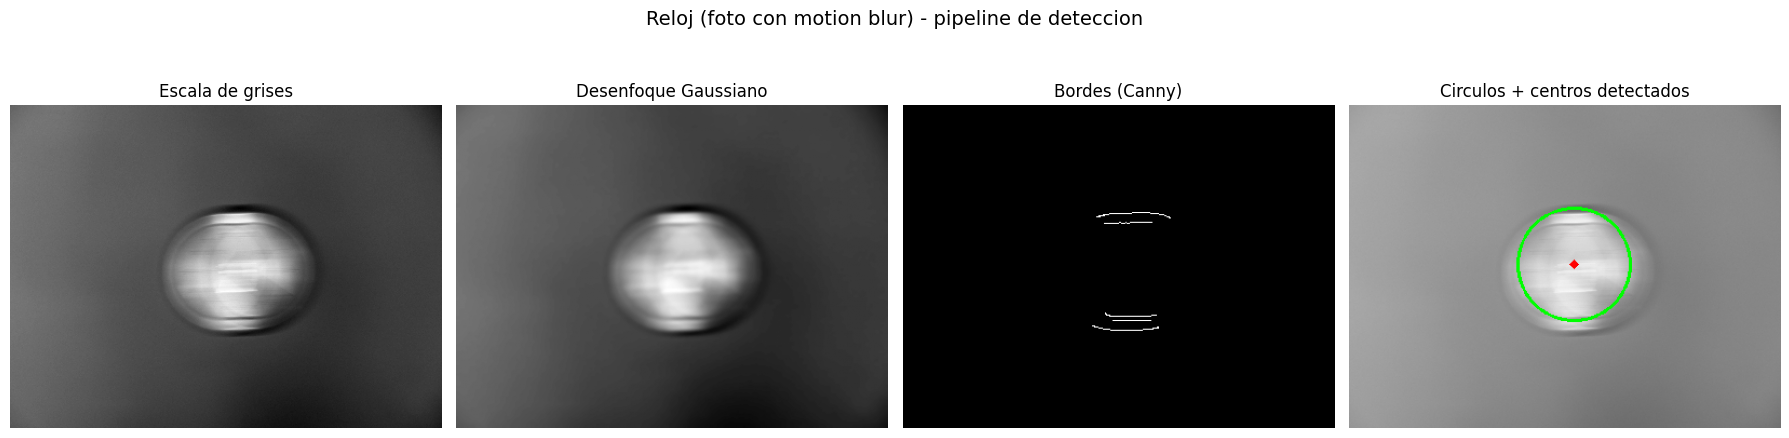


[moon] 3 circulo(s) detectado(s)
   centro=(119, 87)  radio=25px
   centro=(247, 464)  radio=15px
   centro=(275, 451)  radio=12px


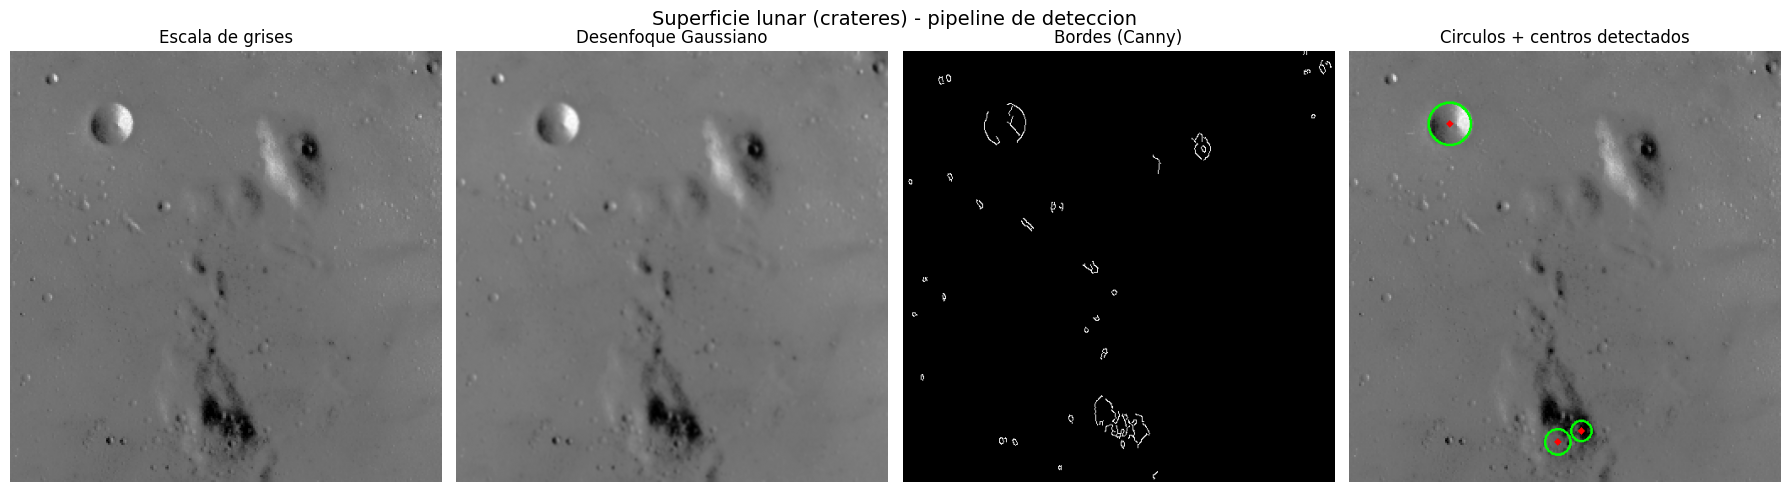


Listo. Salida en 'img_out/': 3 figuras *_proceso.png + centros.json (con los 3 casos juntos).


In [4]:
"""
Deteccion de centros de objetos circulares mediante la Transformada de Hough
(cv2.HoughCircles), replicando la tecnica vista en clase (Clase 4 - deteccion
de monedas) y extendiendola a otras dos imagenes de dominios distintos.

Al correrlo, cada caso se muestra en pantalla (plt.show) y ademas se guarda
una sola figura combinada por caso en la carpeta img_out/. Los centros
detectados de los 3 casos quedan juntos en img_out/centros.json.

Autor: Ferre
"""

import json
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import skimage.data as skdata


def cargar_imagenes_fuente():
    """Devuelve las 3 imagenes de muestra (offline, publicas) como arrays.

    - coins: foto clasica de 24 monedas sobre fondo oscuro (mismo tipo de
      imagen que la del notebook de clase).
    - clock: foto de un reloj de pared con motion blur (un solo objeto
      circular, mas dificil por el desenfoque de movimiento).
    - moon: superficie lunar con crateres (varios objetos circulares de
      distinto tamano, en un dominio totalmente distinto: fotografia
      astronomica en vez de fotografia de objetos cotidianos).
    """
    return {
        "coins": skdata.coins(),
        "clock": skdata.clock(),
        "moon": skdata.moon(),
    }


def detectar_centros(img_gray, dp, minDist, param1, param2, minRadius, maxRadius, blur_k=7):
    """Aplica el pipeline: gris -> desenfoque gaussiano -> HoughCircles.

    Recibe la imagen ya en escala de grises (2D). Devuelve un diccionario
    con las imagenes intermedias (para graficar) y la lista de centros
    encontrados como [{'x':.., 'y':.., 'r':..}, ...].
    """
    blurred = cv2.GaussianBlur(img_gray, (blur_k, blur_k), 0)
    # Canny solo se calcula con fines ilustrativos (mismos param1/param1*2
    # que usa internamente HoughCircles para el paso de deteccion de bordes)
    edges = cv2.Canny(blurred, param1, param1 * 2)

    circles = cv2.HoughCircles(
        blurred,
        cv2.HOUGH_GRADIENT,
        dp=dp,            # resolucion del acumulador vs. la imagen
        minDist=minDist,  # distancia minima entre centros detectados
        param1=param1,    # umbral alto para Canny (deteccion de bordes)
        param2=param2,    # umbral del acumulador (sensibilidad a "ser circulo")
        minRadius=minRadius,
        maxRadius=maxRadius,
    )

    out = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)
    centros = []
    if circles is not None:
        circles = np.uint16(np.around(circles))
        for x, y, r in circles[0, :]:
            centros.append({"x": int(x), "y": int(y), "r": int(r)})
            cv2.circle(out, (x, y), r, (0, 255, 0), 2)  # contorno detectado
            cv2.circle(out, (x, y), 2, (0, 0, 255), 3)  # centro

    return {
        "gris": img_gray,
        "blur": blurred,
        "bordes": edges,
        "detectado": cv2.cvtColor(out, cv2.COLOR_BGR2RGB),
        "centros": centros,
    }


def figura_proceso(resultado, titulo, path_guardado=None, mostrar=True):
    """Muestra (y opcionalmente guarda) una figura de 4 paneles:
    gris, blur, bordes, resultado con centros marcados."""
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    axes[0].imshow(resultado["gris"], cmap="gray"); axes[0].set_title("Escala de grises"); axes[0].axis("off")
    axes[1].imshow(resultado["blur"], cmap="gray"); axes[1].set_title("Desenfoque Gaussiano"); axes[1].axis("off")
    axes[2].imshow(resultado["bordes"], cmap="gray"); axes[2].set_title("Bordes (Canny)"); axes[2].axis("off")
    axes[3].imshow(resultado["detectado"]); axes[3].set_title("Circulos + centros detectados"); axes[3].axis("off")
    fig.suptitle(titulo, fontsize=14)
    plt.tight_layout()

    if path_guardado:
        plt.savefig(path_guardado, dpi=110, bbox_inches="tight")
    if mostrar:
        plt.show()   # <- abre la ventana con la figura
    else:
        plt.close()


if __name__ == "__main__":
    carpeta = "img_out"
    os.makedirs(carpeta, exist_ok=True)
    imagenes = cargar_imagenes_fuente()

    casos = [
        # nombre, titulo, kwargs de detectar_centros
        ("coins", "Monedas - pipeline de deteccion",
         dict(dp=1.2, minDist=40, param1=50, param2=30, minRadius=15, maxRadius=45)),
        ("clock", "Reloj (foto con motion blur) - pipeline de deteccion",
         dict(dp=1.2, minDist=100, param1=50, param2=30, minRadius=50, maxRadius=200)),
        ("moon", "Superficie lunar (crateres) - pipeline de deteccion",
         dict(dp=1.2, minDist=30, param1=60, param2=28, minRadius=8, maxRadius=40, blur_k=5)),
    ]

    todos_los_centros = {}
    for nombre, titulo, kwargs in casos:
        resultado = detectar_centros(imagenes[nombre], **kwargs)

        print(f"\n[{nombre}] {len(resultado['centros'])} circulo(s) detectado(s)")
        for c in sorted(resultado["centros"], key=lambda c: -c["r"]):
            print(f"   centro=({c['x']}, {c['y']})  radio={c['r']}px")

        todos_los_centros[nombre] = resultado["centros"]

        # Muestra la figura en pantalla y guarda una sola imagen combinada
        figura_proceso(
            resultado, titulo,
            path_guardado=f"{carpeta}/{nombre}_proceso.png",
            mostrar=True,
        )

    with open(f"{carpeta}/centros.json", "w") as f:
        json.dump(todos_los_centros, f, indent=2)

    print(f"\nListo. Salida en '{carpeta}/': "
          f"3 figuras *_proceso.png + centros.json (con los 3 casos juntos).")